# Linear Regression with TensorFlow (Keras)
This notebook demonstrates a simple linear regression example using TensorFlow and Keras. We will:
- Generate synthetic data
- Build and train a simple linear model
- Visualize the results and training loss.

## Importing Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

## Generating Synthetic Data
We generate data based on the equation $y = 4 + 3x + \text{noise}$. This helps us simulate real-world data with some randomness.

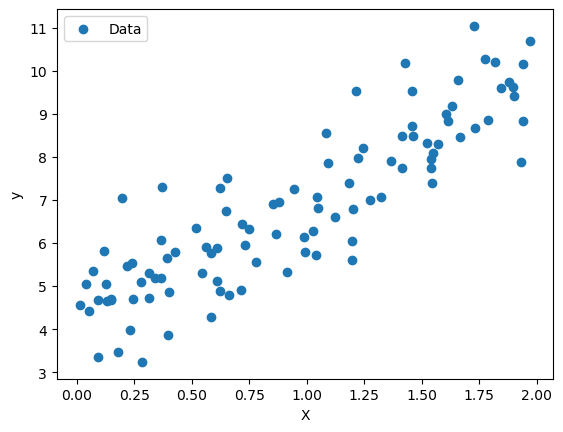

In [2]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # Input feature
y = 4 + 3 * X + np.random.randn(100, 1)  # True line: y = 4 + 3x + noise

plt.scatter(X, y, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Building the Linear Model
We use Keras to create a simple linear regression model with a single dense layer.

In [3]:
model = Sequential([
    Dense(1, input_dim=1, activation='linear')  # Single perceptron with linear activation
])

c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Show the detail of model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## Checking Initial Weights and Bias
Before training, we inspect the initial weights and bias of the model.

In [5]:
initial_weights, initial_bias = model.layers[0].get_weights()
print("Initial weight:", initial_weights[0][0])
print("Initial bias:", initial_bias[0])

Initial weight: 0.84722865
Initial bias: 0.0


## Compiling the Model
We compile the model with the Stochastic Gradient Descent (SGD) optimizer and Mean Squared Error (MSE) loss.

In [6]:
model.compile(optimizer=SGD(learning_rate=0.01), loss='mean_squared_error')

## Training the Model
We train the model for 500 epochs and record the training loss.

In [7]:
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 35.3023  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.6876 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18.5126 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.3849 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.9423  
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6530 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7634 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5137 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5772 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9572 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4720 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0893 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8400 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6383 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4935 
Epoch 16/200


## Trained Weights and Bias
After training, we display the updated weights and bias.

In [8]:
weights, bias = model.layers[0].get_weights()
print("Trained weight:", weights[0][0])
print("Trained bias:", bias[0])

Trained weight: 2.8416057
Trained bias: 4.130278


## Making Predictions
Using the trained model, we predict outputs for the input data.

In [9]:
y_pred = model.predict(X)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


## Visualizing the Results
We plot the original data points and the model's predictions.

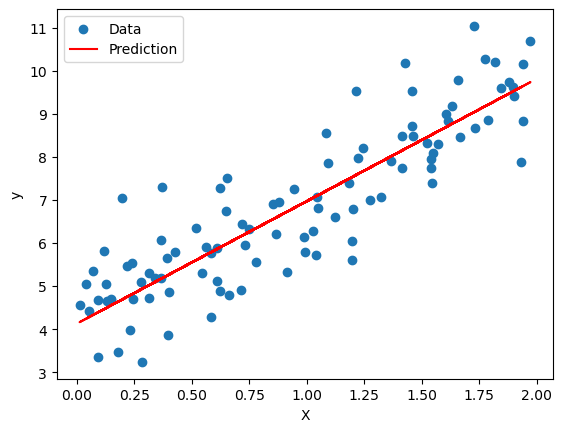

In [10]:
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Plotting the Training Loss
We visualize how the loss decreases over epochs.

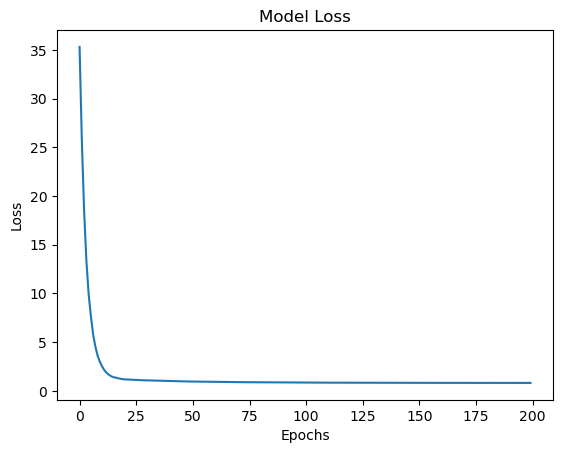

In [11]:
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

-------
-------

# Try with the Polynomial line

## Generating Synthetic Data
We generate data based on the equation $y = x^2 + \text{noise}$. This helps us simulate real-world data with some randomness.

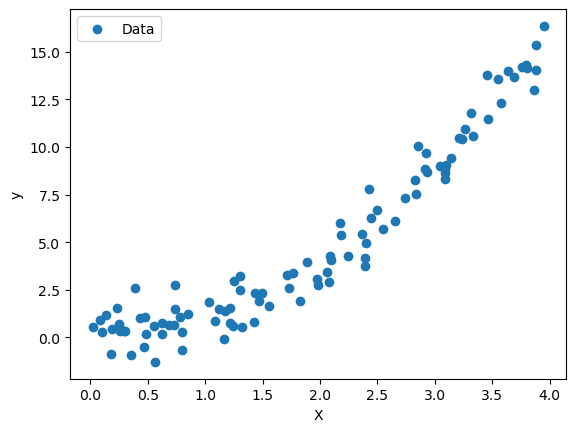

In [12]:
np.random.seed(42)
X = 4 * np.random.rand(100, 1)  # Input feature
y = X**2 + np.random.randn(100, 1)  # True line: y = x^2 + noise

plt.scatter(X, y, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Build Model and Training again

In [13]:
model = Sequential([
    Dense(1, input_dim=1, activation='linear')  # Single perceptron with linear activation
])

# Show the detail of model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
initial_weights, initial_bias = model.layers[0].get_weights()
print("Initial weight:", initial_weights[0][0])
print("Initial bias:", initial_bias[0])

Initial weight: 0.19542181
Initial bias: 0.0


In [15]:
model.compile(optimizer=SGD(learning_rate=0.01), loss='mean_squared_error')
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 34.0188 
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 17.8124 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.7143 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5302 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2957 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.6500 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1079 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0308 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.8023 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6464 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5670 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.4793 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.3588 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2941 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2482 
Epoch 16/200
4/4

In [16]:
weights, bias = model.layers[0].get_weights()
print("Trained weight:", weights[0][0])
print("Trained bias:", bias[0])

Trained weight: 3.7359695
Trained bias: -2.1626172


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


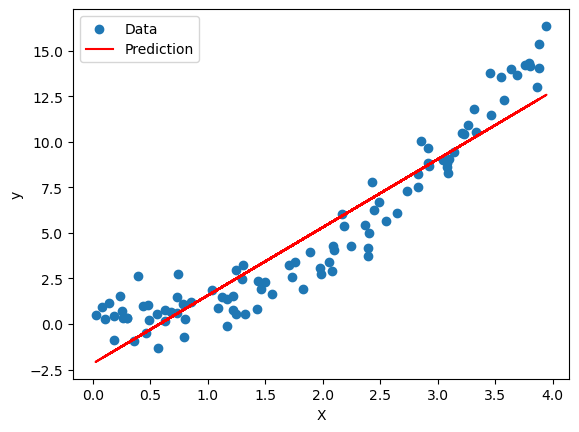

In [17]:
y_pred = model.predict(X)
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()